In [65]:
import torch 
import torch_geometric
from torch_geometric.data import Data, DataLoader, InMemoryDataset
import numpy as np
import matplotlib.pyplot as plt
import os
from torch import nn, Tensor
from sklearn.datasets import make_moons
import torch.nn.functional as F
from torch.autograd import grad
from torchdiffeq import odeint
from torch.utils.data import  TensorDataset
from torchvision import datasets, transforms
import math

In [66]:
trajectories = [np.load(f"../../data/boids/raw/{f}") for f in os.listdir("../../data/boids/raw") if f.endswith(".npy")]
print(len(trajectories))

26


In [67]:
print("Single trajectory shape:")
print(trajectories[0].shape)
print("The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)")

Single trajectory shape:
(1000, 25, 4)
The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)


In [68]:
# Print the mean, std, min and max of the boid positions, velocities
positions = np.array([t[:, :, :2] for t in trajectories])
velocities = np.array([t[:, :, 2:] for t in trajectories])

print("Position mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(positions),2), round(np.std(positions),2), round(np.min(positions), 2), round(np.max(positions), 2))
print()
print("Velocity mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(velocities),2), round(np.std(velocities),2), round(np.min(velocities), 2), round(np.max(velocities), 2))

Position mean, std, min, max:
500.32 290.61 0.0 1000.0

Velocity mean, std, min, max:
-0.35 2.96 -6.0 6.0


In [69]:
def plot_state(trajectory, timestep):
    fig, ax = plt.subplots()
    # Plot dots for the boids
    ax.scatter(trajectory[timestep, :, 0], trajectory[timestep, :, 1])
    # plot the boid velocities as arrows
    for i in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        ax.arrow(trajectory[timestep, i, 0], trajectory[timestep, i, 1], trajectory[timestep, i, 2]*5, trajectory[timestep, i, 3]*5)
    return ax

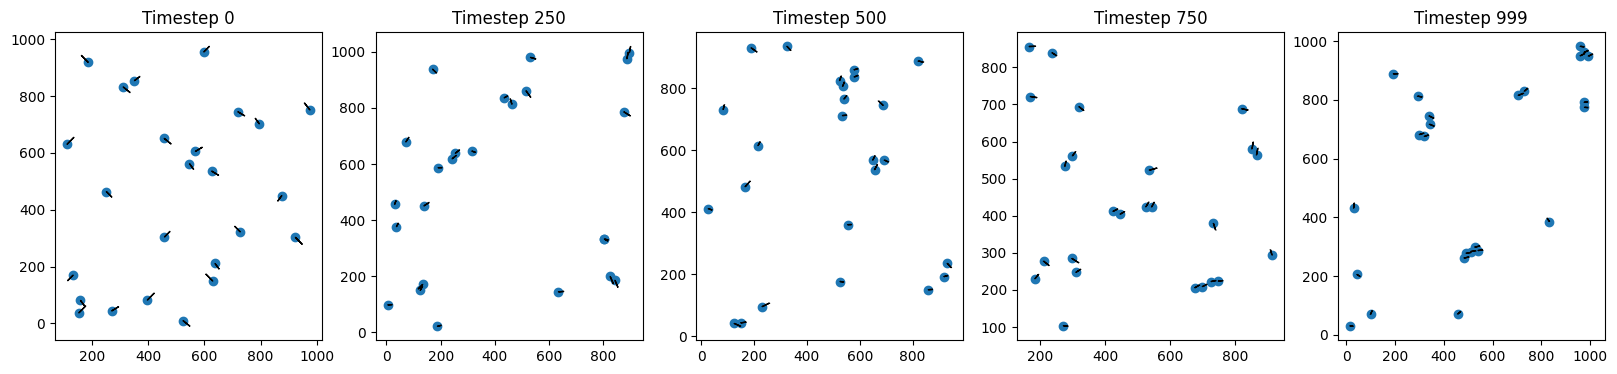

In [70]:
# Plot timesteps 0, 250, 500, 750, 999 for the first trajectory
trajectory = trajectories[0]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate([0, 250, 500, 750, 999]):
    axs[i].set_title(f"Timestep {t}")
    # Plot dots for the boids
    axs[i].scatter(trajectory[t, :, 0], trajectory[t, :, 1])
    # plot the boid velocities as arrows
    for j in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        axs[i].arrow(trajectory[t, j, 0], trajectory[t, j, 1], trajectory[t, j, 2]*5, trajectory[t, j, 3]*5)
plt.show()

In [71]:
class Boids_Dataset(InMemoryDataset):
    def __init__(self, raw_data_path, processed_data_path, root=None,
                 transform=None, pre_transform=None, post_transform=None,
                 solution_idx_range=(0, 25), timesteps=1000,
                 processed_file_name="AR1_Boids_Equivariant.pt", L=1000):
        self.raw_data_path = raw_data_path
        self.processed_data_path = processed_data_path
        self.solution_idx_range = solution_idx_range
        self.timesteps = timesteps
        self.processed_file_name = processed_file_name
        self.pre_transform = pre_transform
        self.transform = transform
        self.post_transform = post_transform
        self.L = L
        super(Boids_Dataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def processed_file_names(self):
        return [self.processed_file_name]

    @property
    def raw_file_names(self):
        return [pfn for pfn in os.listdir(self.raw_data_path)
                if (self.solution_idx_range[0] <= int(pfn.split("_")[-1][:-4]) < self.solution_idx_range[1])]

    def download(self):
        pass

    def process(self):
        max_forward_steps = 5
        data_list = []
        all_init_positions = []   
        vmax = 0.0
        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))  
            vels = trajectory[:, :, 2:]  
            vmax = max(vmax, np.abs(vels).max())
        if vmax == 0:
            vmax = 1.0

        print(f"[Normalization] Using L={self.L}, vmax={vmax:.4f}")

        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))

            init_pos = torch.tensor(trajectory[0, :, :2], dtype=torch.float)  
            all_init_positions.append(init_pos)

            for t in range(trajectory.shape[0] - max_forward_steps):
                # current state
                pos_t = torch.tensor(trajectory[t, :, :2], dtype=torch.float) / self.L
                vel_t = torch.tensor(trajectory[t, :, 2:], dtype=torch.float) / vmax
                x = torch.cat([pos_t, vel_t], dim=-1) 

                pos_next = torch.tensor(trajectory[t+1, :, :2], dtype=torch.float) / self.L
                vel_next = torch.tensor(trajectory[t+1, :, 2:], dtype=torch.float) / vmax
                y = torch.cat([pos_next, vel_next], dim=-1)

                N = pos_t.shape[0]
                edge_index = torch.combinations(torch.arange(N), r=2, with_replacement=False).T
                edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
                senders, receivers = edge_index

                # relative displacement as edge attribute
                rel_disp = pos_t[receivers] - pos_t[senders]
                rel_disp = rel_disp - torch.round(rel_disp)
                edge_attr = rel_disp

                data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
                data_list.append(data)

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])

        all_init_positions = torch.stack(all_init_positions)   
        torch.save(all_init_positions, os.path.join(self.processed_data_path,
                                                    "positions_" + self.processed_file_name))
        print(f"Saved initial positions: {all_init_positions.shape}")
        
    def __getitem__(self, idx):
        return self.get(idx)
    
    def __repr__(self):
        return f'{self.__class__.__name__}({len(self)})'

In [72]:
train_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(0, 15), timesteps=1000, processed_file_name="Boids4.pt")
validation_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(16, 25), timesteps=1000, processed_file_name="VAL_Boids4.pt")

print(train_dataset)
print(validation_dataset)


data_0 = train_dataset[0]
print(data_0)
print(data_0.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_0.x[0,:])

Boids_Dataset(14925)
Boids_Dataset(8955)
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7190,  0.7450,  0.8333, -0.5000])


In [73]:
print(data_0.y[0,:])

data_1 = train_dataset[1]
print(data_1)
print(data_1.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_1.x[0,:])

print(data_1.y[0,:])

data_2 = train_dataset[2]
print(data_2)
print(data_2.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_2.x[0,:])

tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])


In [74]:
import torch
import torch.nn as nn
import torch.optim as optim

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.nn import MessagePassing

class EdgeGNNVectorField(MessagePassing):
    def __init__(self, hidden_dim=128, n_layers=4):
        super().__init__(aggr='mean')
        self.n_layers = n_layers

        # Edge MLP (shared across layers or separate per layer)
        self.edge_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(4, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])

        # Node MLP per layer
        self.node_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim + 4  + 1, hidden_dim), # added condition size
                nn.ReLU(),
                nn.Linear(hidden_dim, 4)
            ) for _ in range(n_layers)
        ])

    def forward(self, x_t,  edge_index, t):
        current_edge_attr = self.compute_edge_attr(x_t, edge_index)
        h = x_t
        for i in range(self.n_layers):
            edge_msg = self.edge_mlps[i](current_edge_attr)
            # Message passing
            aggregated_messages = self.propagate(edge_index, x=h, edge_attr=edge_msg)

            node_input = torch.cat([aggregated_messages, h, t], dim=1)

            # Update node features
            h = self.node_mlps[i](node_input)
        return h

    def message(self, x_j, edge_attr):
        return edge_attr
    
    def compute_edge_attr(self, x, edge_index, L=1.0 ):
        row, col = edge_index
        
        pos = x[:, :2]
        vel = x[:, 2:]
        
        rel_pos = pos[col] - pos[row]
        rel_pos = rel_pos - L * torch.round(rel_pos / L)

        rel_vel = vel[col] - vel[row]
        return torch.cat([rel_pos, rel_vel], dim=1)

    @torch.no_grad()
    def generate(self, x0, edge_index, n_steps=50, dt=0.02, sigma=0.1, L=1.0):
        device = next(self.parameters()).device
        x = torch.randn_like(x0).to(device) 
        traj = [x.cpu()]

        for i in range(n_steps):
            t_val = 1.0 - (i / n_steps) 
            t = torch.full((x.size(0), 1), t_val, device=device)
            
            v = self.forward(x, edge_index, t)
            
    
            x = x - dt * (v + sigma * x)
            if sigma > 0:
                x = x + (2 * dt * sigma)**0.5 * torch.randn_like(x)

            x[:, :2] = x[:, :2] % L 
            traj.append(x.cpu())

        return torch.stack(traj)


def GFM_training_graph_conditional_loader(
    VF, dataset, n_epochs=1000, sigma=0.1,
    device="cuda", n_time_samples=8, batch_size=16
):
    """
    Conditional Flow Matching training with time bundling using a PyG DataLoader.

    Args:
        VF: Vector field model (EdgeGNNVectorField)
        dataset: PyG dataset or list of Data objects
        n_epochs: Number of training epochs
        sigma: Noise scale
        device: 'cuda' or 'cpu'
        n_time_samples: Number of time samples per node
        batch_size: Number of graphs per batch
    """

    VF = VF.to(device)
    optimizer = optim.Adam(VF.parameters(), lr=1e-4)
    loss_fn = nn.MSELoss()
    loss_hist = []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    print("Starting Conditional Flow Matching Training (batched via DataLoader + time bundling)...")

    for epoch in range(n_epochs):
        VF.train()
        total_loss = 0.0
        total_nodes = 0

        for data in loader:
            data = data.to(device)

            x_1 = data.y          # [N, D]
            edge_index = data.edge_index  # [2, E]
            N = x_1.size(0)

            # --- Time bundling ---
            t = torch.rand(N, n_time_samples, device=device)

            x_1_exp = x_1.unsqueeze(1).expand(-1, n_time_samples, -1)

            # 1. Define the probability path p_t(x | x_0, x_1)
            # Sample from N((1-t)x_0 + t*x_1, sigma^2 * I)
            mean_t = t.unsqueeze(-1) * x_1.unsqueeze(1)
            std_t = ((t * sigma - t + 1).unsqueeze(-1))
            x_t = mean_t + std_t * torch.randn_like(mean_t)
            x_t[:, :2] = x_t[:, :2] % 1.0

            # target u_t(x|x1)
            u_t = (x_1.unsqueeze(1) - (1 - sigma) * x_t) / (1 - (1 - sigma) * t.unsqueeze(-1))

            # Flatten [N, K, D] → [N*K, D]
            x_t_flat = x_t.reshape(-1, x_t.size(-1))

            t_flat = t.reshape(-1, 1)
            u_flat = u_t.reshape(-1, x_1.size(-1))

            # Forward pass
            pred_u_flat = VF(x_t_flat,  edge_index, t_flat)
            loss = loss_fn(pred_u_flat, u_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * N
            total_nodes += N

            del x_t,  x_1_exp, mean_t, u_t, x_t_flat,  t_flat, u_flat
            torch.cuda.empty_cache()

        avg_loss = total_loss / total_nodes
        loss_hist.append(avg_loss)

        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:04d} | Avg Loss: {avg_loss:.6f}")

    return VF, loss_hist


Starting Conditional Flow Matching Training (batched via DataLoader + time bundling)...
Epoch 0000 | Avg Loss: 1.380176
Epoch 0010 | Avg Loss: 1.062448
Epoch 0020 | Avg Loss: 1.017024
Epoch 0030 | Avg Loss: 1.001678
Epoch 0040 | Avg Loss: 0.953099
Epoch 0050 | Avg Loss: 0.940871
Epoch 0060 | Avg Loss: 0.903977
Epoch 0070 | Avg Loss: 0.887443
Epoch 0080 | Avg Loss: 0.855067
Epoch 0090 | Avg Loss: 0.851811
Epoch 0099 | Avg Loss: 0.847998


Text(0.5, 1.0, 'Training loss')

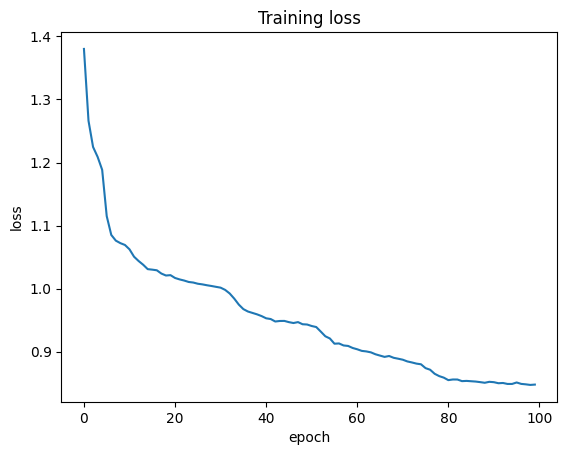

In [92]:
VF = EdgeGNNVectorField().to("cuda")
VF_GFM, loss_hist_GFM = GFM_training_graph_conditional_loader(VF, train_dataset, n_epochs=100,batch_size=16, n_time_samples=8, sigma=0.1)
plt.plot(loss_hist_GFM)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')

Rollout

In [80]:
@torch.no_grad()
def generate_rollout(VF, x0, edge_index, n_steps=1000, dt=0.001, sigma=0.0, rollout_iters=30, L=1.0):
    device = next(VF.parameters()).device
    x0 = x0.to(device)
    edge_index = edge_index.to(device)

    trajs = []
    for _ in range(rollout_iters):
        for i in range(n_steps):
            t_val = 1.0 - (i / n_steps) 
            t = torch.full((x0.size(0), 1), t_val, device=device)
            #x = torch.randn_like(x0).to(device) 
            
            v = VF(x0,  edge_index, t)
            
            x0 = x0 - dt * (v + sigma * x0)
            if sigma > 0:
                x0 = x0 + (2 * dt * sigma)**0.5 * torch.randn_like(x0)

            x0[:, :2] = x0[:, :2] % L 
        #x0 = x
        trajs.append(x0.cpu().unsqueeze(0))
    return torch.cat(trajs, dim=0)

In [81]:
data = validation_dataset[0].to("cuda")
x0 = data.x.to("cuda")

rollouts = generate_rollout(VF, x0, data.edge_index, n_steps=1000, dt=0.001, sigma=0.0, rollout_iters=100, L=1.0)

In [82]:
rollouts.shape

torch.Size([100, 25, 4])

In [83]:
import io
import imageio

In [84]:
def create_rollout_gif(trajectory, output_filename="rollout.gif", L=1.0, duration=50, dot_size=30, color='royalblue'):
    """
    Creates an animated GIF from a single trajectory tensor.

    Args:
        trajectory (torch.Tensor): A tensor of shape [n_steps, num_nodes, 4].
        output_filename (str): The path to save the GIF file.
        L (float): The box size, used for setting plot limits.
        duration (int): The duration of each frame in milliseconds.
        dot_size (int): The size of the scattered points.
        color (str): The color of the points.
    """
    frames = []
    n_steps = trajectory.shape[0]
    
    print(f"Creating GIF with {n_steps} frames...")
    
    for i in range(n_steps):
        # Use an in-memory buffer to avoid saving temporary files
        buf = io.BytesIO()
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Get the positions (x, y coordinates) at the current timestep
        positions = trajectory[i, :, :2].numpy()
        
        ax.scatter(positions[:, 0], positions[:, 1], s=dot_size, color=color, alpha=0.8)
        
        # --- Style the plot ---
        ax.set_title(f"System Evolution | Timestep: {i+1}/{n_steps}")
        ax.set_xlabel("X-coordinate")
        ax.set_ylabel("Y-coordinate")
        ax.set_xlim(0, L)
        ax.set_ylim(0, L)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Save the current plot to the buffer
        plt.savefig(buf, format='png', dpi=100)
        buf.seek(0)
        
        # Add the image from the buffer to our list of frames
        frames.append(imageio.imread(buf))
        
        # Close the plot to free memory
        plt.close(fig)

    # Save the collected frames as a GIF
    imageio.mimsave(output_filename, frames, duration=duration, loop=0)
    print(f"Successfully saved animation to {output_filename}")

In [85]:
create_rollout_gif(rollouts, output_filename="boids_data_gaussian.gif", L=1, duration=500, dot_size=30, color='blue')

Creating GIF with 100 frames...


C:\Users\nasso\AppData\Local\Temp\ipykernel_24712\3842622182.py:43: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))


Successfully saved animation to boids_data_gaussian.gif


Trajectory created using euler

In [ ]:
data = validation_dataset[0].to("cuda")
x0 = data.x.to("cuda")

x0 = torch.randn_like(x0).to("cuda")
x0[:, :2] = x0[:, :2] % 1.0

n_steps = 200
dt = 1.0 / n_steps  # integrate from t=0 to t=1
t = torch.zeros_like(x0[:, :1])  # start at t=0

trajectory = [x0.detach().cpu()]

for step in range(n_steps):
    v_t = VF_GFM(x0, data.edge_index, t)  # predicted velocity
    #print(v_t)
    x0 = x0 + dt * v_t          # Euler integration
    t = t + dt                    # advance time

    trajectory.append(x0.detach().cpu())


tensor([[-0.5353, -0.1950, -1.2449, -1.2016],
        [-0.1701,  0.0572,  2.9057,  1.3084],
        [ 0.1808,  0.2210, -0.5481,  0.0932],
        [ 0.4982,  0.3088, -1.8218,  0.5766],
        [-0.0336, -0.3729,  1.7811,  0.0133],
        [-0.2328, -0.2621, -0.6303, -0.5223],
        [-0.3137, -0.1571, -1.7668, -1.1396],
        [ 0.2845, -0.0690,  1.1582,  0.2471],
        [-0.3987, -0.2766,  2.0881,  1.6625],
        [-0.3599, -0.2083,  0.4131,  1.5799],
        [ 0.3093,  0.2396,  0.4992, -0.4878],
        [ 0.3057,  0.1137,  0.7792,  0.5937],
        [ 0.0111, -0.2675, -0.5150,  1.5588],
        [ 0.1698, -0.2033, -1.4496, -0.0679],
        [-0.0664,  0.2128, -0.8916, -2.0382],
        [-0.4677,  0.2484,  0.8369, -2.0435],
        [-0.1646, -0.3252, -1.3315,  0.0386],
        [ 0.0202,  0.0145, -0.6410,  0.1833],
        [ 0.0458, -0.3353,  1.7912,  0.0704],
        [-0.0876, -0.2672,  3.2315,  0.2378],
        [-0.0076,  0.2447, -0.3154,  0.1510],
        [ 0.2745, -0.2227,  1.0415

In [87]:
len(trajectory)
trajectory = torch.stack(trajectory)  # shape [n_steps+1, N, D]


In [88]:
create_rollout_gif(trajectory, output_filename="boids_data_euler.gif", L=1, duration=500, dot_size=30, color='orange')

Creating GIF with 201 frames...


C:\Users\nasso\AppData\Local\Temp\ipykernel_24712\3842622182.py:43: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))


Successfully saved animation to boids_data_euler.gif
